# Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Read the dataset

In [2]:
df = pd.read_csv("Loan_default_cleaned.csv")

print(df.head())
print(df.shape)
print(df.columns)

       loanid       age    income  ...  loanpurpose  hascosigner  default
0  I38PQUQS96  0.833990  0.089693  ...            4            1        0
1  HPSK72WA7R  1.701221 -0.823021  ...            4            1        0
2  C1OZ6DPJ8Y  0.166888  0.043854  ...            0            0        1
3  V2KKSFM3UN -0.767053 -1.303452  ...            1            0        0
4  EY08JDHTZP  1.100830 -1.592855  ...            0            0        0
[5 rows x 18 columns]
(255347, 18)
Index(['loanid', 'age', 'income', 'loanamount', 'creditscore',
       'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm',
       'dtiratio', 'education', 'employmenttype', 'maritalstatus',
       'hasmortgage', 'hasdependents', 'loanpurpose', 'hascosigner',
       'default'],
      dtype='str')


# Separate Input and Output

In [3]:
x = df.drop(columns = ["loanid", "default"])
y = df["default"]

In [4]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (255347, 16)
y shape: (255347,)


# Split the dataset

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Create the AdaBoost model

In [25]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Train the model

In [26]:
ada.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.12,0.27,0.38,...,0.5 ,0.5 ,0.5 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[1.01,0.51,0.25,...,0. ,0. ,0. ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](16,)","[0.47,0.12,0.06,...,0.02,0.01,0.02]"


# Make predictions

In [27]:
y_pred = ada.predict(x_test)

In [28]:
y_prob_ada = ada.predict_proba(x_test)[:, 1]

# Check Training vs Testing Score

In [29]:
train_score_ada = ada.score(x_train, y_train)
test_score_ada = ada.score(x_test, y_test)

print("Training Score:", train_score_ada)
print("Testing Score:", test_score_ada)
print("Difference:", train_score_ada - test_score_ada)

Training Score: 0.8851902074144422
Testing Score: 0.8863912277266497
Difference: -0.0012010203122074792


# Accuracy

In [30]:
accuracy_ada = accuracy_score(y_test, y_pred)

print("AdaBoost Accuracy:", accuracy_ada)

AdaBoost Accuracy: 0.8863912277266497


# Confusion Matrix

In [31]:
cm_ada = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm_ada)

Confusion Matrix:
[[45084    86]
 [ 5716   184]]


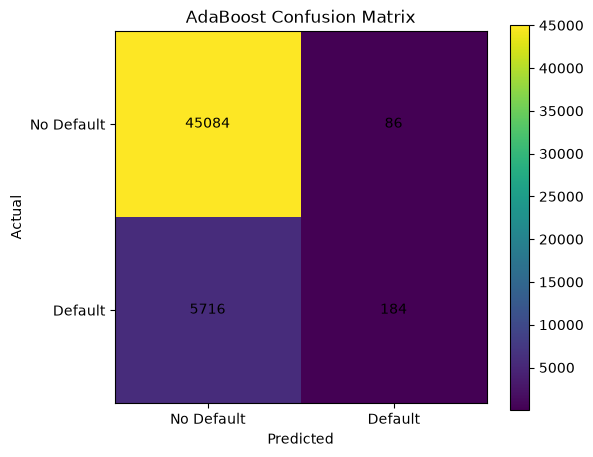

In [32]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_ada)

plt.title("AdaBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_ada[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

# Classification Report

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support
           0       0.89      1.00      0.94     45170
           1       0.68      0.03      0.06      5900
    accuracy                           0.89     51070
   macro avg       0.78      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070


# ROC-AUC

In [34]:
roc_auc_ada = roc_auc_score(y_test, y_prob_ada)

print("AdaBoost ROC-AUC:", roc_auc_ada)

AdaBoost ROC-AUC: 0.7534472238586433


# STEP 1: Model Evaluation (Class 1 - Default Metrics)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_ada = accuracy_score(y_test, y_pred)
precision_ada = precision_score(y_test, y_pred)
recall_ada = recall_score(y_test, y_pred)
f1_ada = f1_score(y_test, y_pred)

print("Accuracy :", accuracy_ada)
print("Precision:", precision_ada)
print("Recall   :", recall_ada)
print("F1-score :", f1_ada)


Accuracy : 0.8863912277266497
Precision: 0.6814814814814815
Recall   : 0.031186440677966103
F1-score : 0.05964343598055105


# STEP 3: 5-Fold Cross-Validation


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores_ada = cross_val_score(
    ada,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("AdaBoost CV Scores:", cv_scores_ada)
print("Mean CV Score:", cv_scores_ada.mean())
print("Standard Deviation:", cv_scores_ada.std())


AdaBoost CV Scores: [0.88535344 0.88501077 0.88537511 0.88532615 0.88505691]
Mean CV Score: 0.8852244750253042
Standard Deviation: 0.0001571038682386724
